In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
df2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])

# Normalize df2 timezone-aware timestamps to naive UTC-5 local time
df2["timestamp"] = pd.to_datetime(df2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)

# Merge and sort
df = pd.concat([df1, df2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)

print(f"Combined range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Total rows: {len(df):,}")
df.head()

Combined range: 2022-01-01 00:00:00 → 2026-03-31 23:00:00
Total rows: 37,169


,timestamp,kwh
0,2022-01-01 00:00:00,1.236
1,2022-01-01 01:00:00,1.898
2,2022-01-01 02:00:00,1.611
3,2022-01-01 03:00:00,1.522
4,2022-01-01 04:00:00,1.709


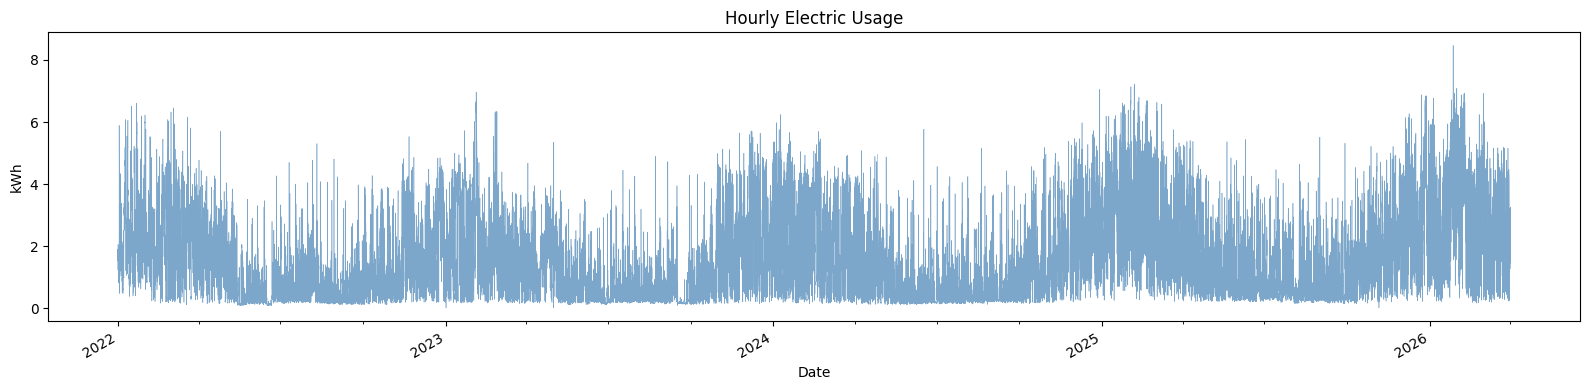

In [15]:
# Hourly
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df["timestamp"], df["kwh"], linewidth=0.4, color="steelblue", alpha=0.7)
ax.set_title("Hourly Electric Usage")
ax.set_xlabel("Date")
ax.set_ylabel("kWh")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

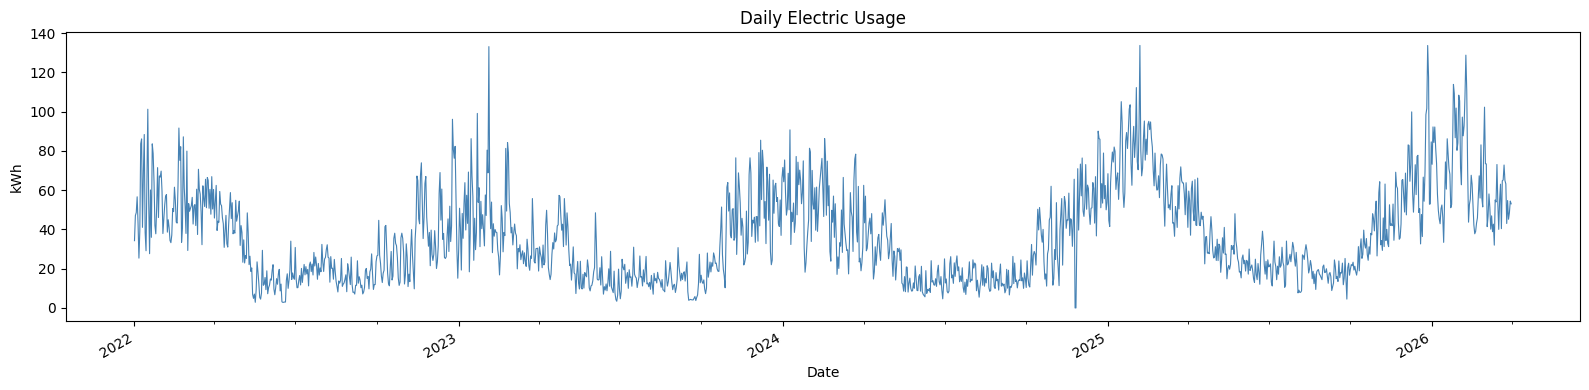

In [16]:
# Daily
daily = df.resample("D", on="timestamp")["kwh"].sum()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily.index, daily.values, linewidth=0.8, color="steelblue")
ax.set_title("Daily Electric Usage")
ax.set_xlabel("Date")
ax.set_ylabel("kWh")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

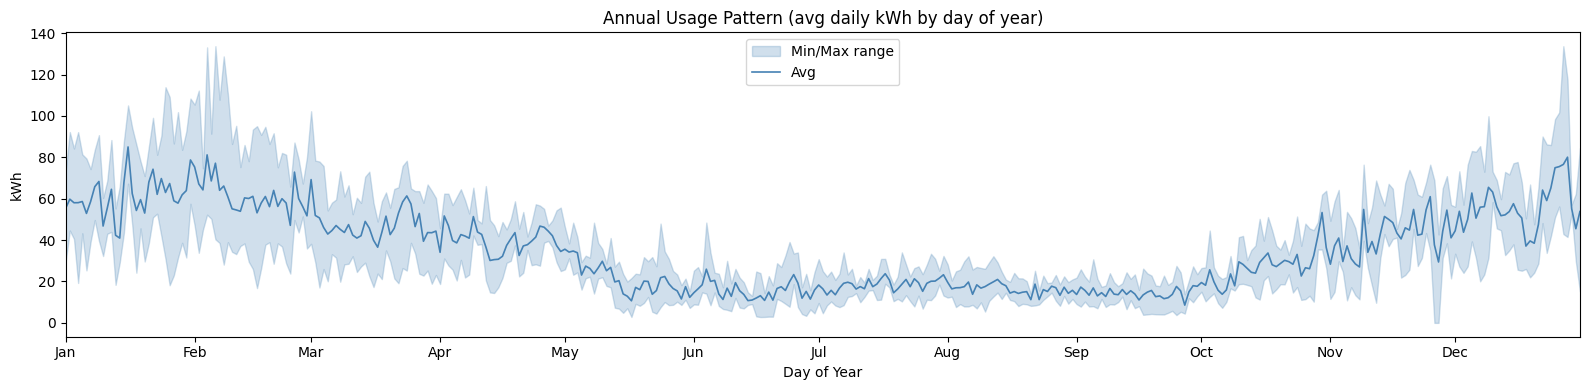

In [17]:
# Annual pattern (avg daily kWh per day-of-year, across all years)
daily_doy = df.resample("D", on="timestamp")["kwh"].sum().reset_index()
daily_doy["doy"] = daily_doy["timestamp"].dt.day_of_year

by_doy = daily_doy.groupby("doy")["kwh"]
avg = by_doy.mean()
low = by_doy.min()
high = by_doy.max()

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(avg.index, low.values, high.values, color="steelblue", alpha=0.25, label="Min/Max range")
ax.plot(avg.index, avg.values, color="steelblue", linewidth=1.2, label="Avg")
ax.set_title("Annual Usage Pattern (avg daily kWh by day of year)")
ax.set_xlabel("Day of Year")
ax.set_ylabel("kWh")
ax.set_xlim(1, 365)
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.legend()
plt.tight_layout()
plt.show()

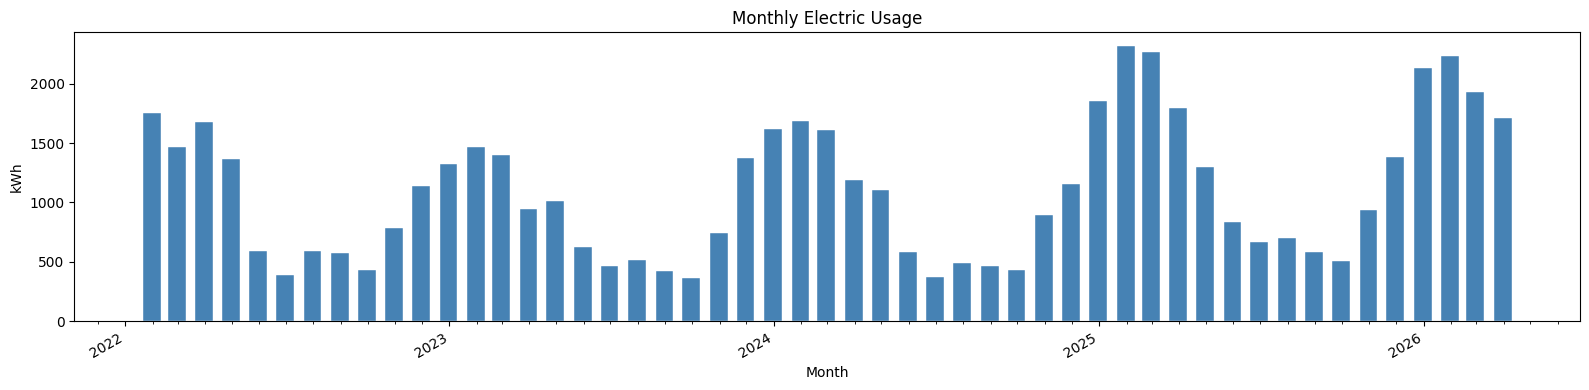

In [18]:
# Monthly
monthly = df.resample("ME", on="timestamp")["kwh"].sum()

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(monthly.index, monthly.values, width=20, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_title("Monthly Electric Usage")
ax.set_xlabel("Month")
ax.set_ylabel("kWh")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

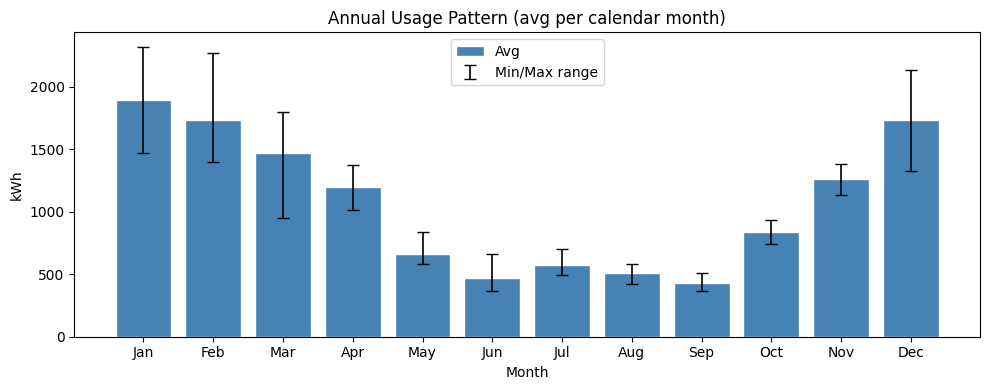

In [19]:
# Annual pattern (avg kWh per calendar month, across all years)
monthly_cal = df.resample("ME", on="timestamp")["kwh"].sum().reset_index()
monthly_cal["month"] = monthly_cal["timestamp"].dt.month

by_month = monthly_cal.groupby("month")["kwh"]
avg = by_month.mean()
low = by_month.min()
high = by_month.max()

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(avg.index, avg.values, color="steelblue", edgecolor="white", label="Avg")
ax.errorbar(avg.index, avg.values,
            yerr=[avg.values - low.values, high.values - avg.values],
            fmt="none", color="black", capsize=4, linewidth=1.2, label="Min/Max range")
ax.set_title("Annual Usage Pattern (avg per calendar month)")
ax.set_xlabel("Month")
ax.set_ylabel("kWh")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend()
plt.tight_layout()
plt.show()

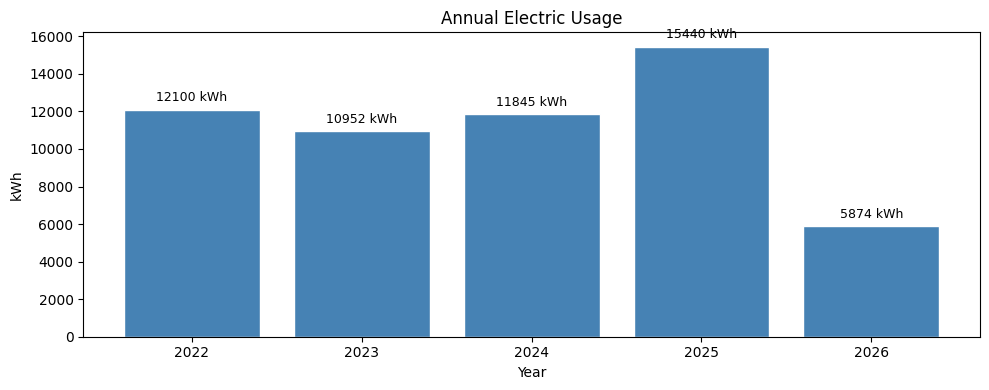

In [20]:
# Annual
annual = df.resample("YE", on="timestamp")["kwh"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(annual.index.year, annual.values, color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.0f kWh", padding=4, fontsize=9)
ax.set_title("Annual Electric Usage")
ax.set_xlabel("Year")
ax.set_ylabel("kWh")
ax.set_xticks(annual.index.year)
plt.tight_layout()
plt.show()